#  Solar Power Generation Dataset

##  What is this dataset?
This dataset comes from *two solar power plants*.  
It records how much electricity is generated at different times of the day.  
The data is collected from *inverters* (machines that convert DC power to AC power).  

It is a *time-series dataset*, which means values are recorded at different time intervals (with Date and Time).


##  Columns in the dataset
1. *DateTime* – The exact date and time when the reading was taken.  
2. *Plant ID* – The ID of the solar plant of 1 or 2.  
3. *Source Key* – A unique code for each inverter inside the plant.  
4. *DC Power (kW)* – Power generated directly from solar panels.  
5. *AC Power (kW)* – Power after conversion by the inverter (this is the usable electricity).  
6. *Daily Yield (kWh)* – Total energy generated in that day by the inverter/plant.  
7. *Total Yield (kWh)* – Total energy generated since the beginning its like meter reading.  


## Why is this dataset useful?
- Helps us *check performance* of solar plants.  
- Helps in *finding faults* if one inverter is not working properly.  
- Can be used to *predict future solar power generation*.  
- Useful for *managing the electricity grid.  
- Good for *research in renewable energy* and *machine learning projects*.  



##  What patterns can we see?
- Power starts low in the *morning, becomes highest at **noon, and drops in the **evening*.  
- *AC power is always a bit less than DC power* because of conversion loss in inverters.  
- Power generation also changes with *seasons* (summer, winter, rainy).  




# Required Dependencies To Install

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
# Here i have loaded the dataset. Basically this dataset is taken by the kaggle.
data = pd.read_csv("C:/Users/abhia/OneDrive/Desktop/PlantD.csv")
data.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [4]:
data.shape

(68778, 7)

In [5]:
data.columns

Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='object')

In [6]:
data.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
68773,17-06-2020 23:45,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,17-06-2020 23:45,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,17-06-2020 23:45,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,17-06-2020 23:45,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0
68777,17-06-2020 23:45,4135001,zVJPv84UY57bAof,0.0,0.0,5910.000,7363272.0


In [7]:
data.isnull

<bound method DataFrame.isnull of               DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0      15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1      15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2      15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3      15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4      15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   
...                 ...       ...              ...       ...       ...   
68773  17-06-2020 23:45   4135001  uHbuxQJl8lW7ozc       0.0       0.0   
68774  17-06-2020 23:45   4135001  wCURE6d3bPkepu2       0.0       0.0   
68775  17-06-2020 23:45   4135001  z9Y9gH1T5YWrNuG       0.0       0.0   
68776  17-06-2020 23:45   4135001  zBIq5rxdHJRwDNY       0.0       0.0   
68777  17-06-2020 23:45   4135001  zVJPv84UY57bAof       0.0       0.0   

       DAILY_YIELD  TOTAL_YIELD  
0            0.000    6259559.0  
1        

In [8]:
# Cheking the null values in the dataset 
data.isna()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
68773,False,False,False,False,False,False,False
68774,False,False,False,False,False,False,False
68775,False,False,False,False,False,False,False
68776,False,False,False,False,False,False,False


In [9]:
data.notnull()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...
68773,True,True,True,True,True,True,True
68774,True,True,True,True,True,True,True
68775,True,True,True,True,True,True,True
68776,True,True,True,True,True,True,True


In [10]:
data.isna().sum()

DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

In [11]:
data.describe()
# overall statistic of the dataset

,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06
std,0.0,4036.457169,394.396439,3145.178309,4.162720e+05
min,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,4135001.0,0.000000,0.000000,0.000000,6.512003e+06
50%,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06
75%,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06
max,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06


In [12]:
data['SOURCE_KEY']

0        1BY6WEcLGh8j5v7
1        1IF53ai7Xc0U56Y
2        3PZuoBAID5Wc2HD
3        7JYdWkrLSPkdwr4
4        McdE0feGgRqW7Ca
              ...       
68773    uHbuxQJl8lW7ozc
68774    wCURE6d3bPkepu2
68775    z9Y9gH1T5YWrNuG
68776    zBIq5rxdHJRwDNY
68777    zVJPv84UY57bAof
Name: SOURCE_KEY, Length: 68778, dtype: object

In [13]:
data['SOURCE_KEY'].unique()

array(['1BY6WEcLGh8j5v7', '1IF53ai7Xc0U56Y', '3PZuoBAID5Wc2HD',
       '7JYdWkrLSPkdwr4', 'McdE0feGgRqW7Ca', 'VHMLBKoKgIrUVDU',
       'WRmjgnKYAwPKWDb', 'ZnxXDlPa8U1GXgE', 'ZoEaEvLYb1n2sOq',
       'adLQvlD726eNBSB', 'bvBOhCH3iADSZry', 'iCRJl6heRkivqQ3',
       'ih0vzX44oOqAx2f', 'pkci93gMrogZuBj', 'rGa61gmuvPhdLxV',
       'sjndEbLyjtCKgGv', 'uHbuxQJl8lW7ozc', 'wCURE6d3bPkepu2',
       'z9Y9gH1T5YWrNuG', 'zBIq5rxdHJRwDNY', 'zVJPv84UY57bAof',
       'YxYtjZvoooNbGkE'], dtype=object)

In [14]:
data['DATE_TIME'].isna()

0        False
1        False
2        False
3        False
4        False
         ...  
68773    False
68774    False
68775    False
68776    False
68777    False
Name: DATE_TIME, Length: 68778, dtype: bool

In [15]:
data['DATE_TIME'].notnull().sum()

np.int64(68778)

In [16]:
data.max()

DATE_TIME      31-05-2020 23:45
PLANT_ID                4135001
SOURCE_KEY      zVJPv84UY57bAof
DC_POWER              14471.125
AC_POWER                1410.95
DAILY_YIELD              9163.0
TOTAL_YIELD           7846821.0
dtype: object

In [17]:
data.min()

DATE_TIME      01-06-2020 00:00
PLANT_ID                4135001
SOURCE_KEY      1BY6WEcLGh8j5v7
DC_POWER                    0.0
AC_POWER                    0.0
DAILY_YIELD                 0.0
TOTAL_YIELD           6183645.0
dtype: object

In [18]:
data.shape

(68778, 7)

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB


In [20]:
data.isnull().sum()

DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

In [21]:
data.dtypes

DATE_TIME       object
PLANT_ID         int64
SOURCE_KEY      object
DC_POWER       float64
AC_POWER       float64
DAILY_YIELD    float64
TOTAL_YIELD    float64
dtype: object

In [52]:
new_data = data.head(500)

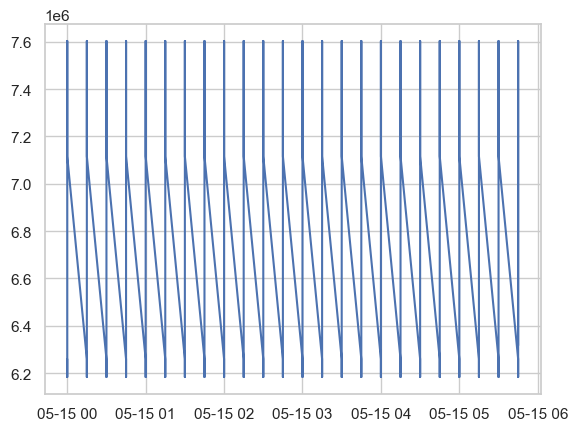

In [53]:
x = new_data['DATE_TIME']
y = new_data['TOTAL_YIELD']
plt.plot(x,y)
plt.show()
# performing the visualization

In [54]:
data['DATE_TIME'] = pd.to_datetime(data['DATE_TIME'], format = '%d-%m-%Y %H:%M')

In [55]:
data['hour'] = data['DATE_TIME'].dt.hour
data['day'] = data['DATE_TIME'].dt.day
data['dayofweek'] = data['DATE_TIME'].dt.dayofweek
data['month'] = data['DATE_TIME'].dt.month
data['year'] = data['DATE_TIME'].dt.year
print(data['hour'].head())

0    0
1    0
2    0
3    0
4    0
Name: hour, dtype: int32


In [56]:
print(data['day'].head())

0    15
1    15
2    15
3    15
4    15
Name: day, dtype: int32


In [57]:
print(data['month'].head())

0    5
1    5
2    5
3    5
4    5
Name: month, dtype: int32


In [58]:
print(data['DATE_TIME'].head())

0   2020-05-15
1   2020-05-15
2   2020-05-15
3   2020-05-15
4   2020-05-15
Name: DATE_TIME, dtype: datetime64[ns]


In [59]:
print(data['DATE_TIME'].dtype)

datetime64[ns]


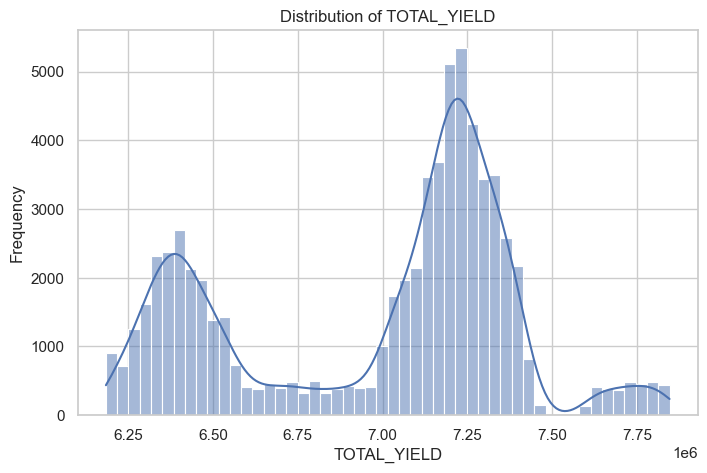

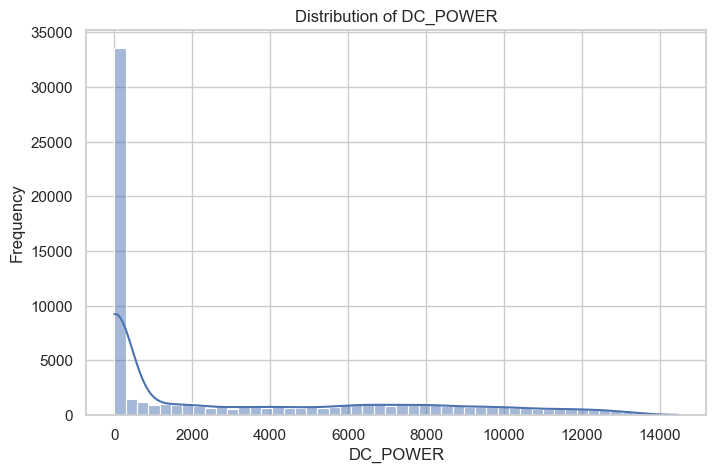

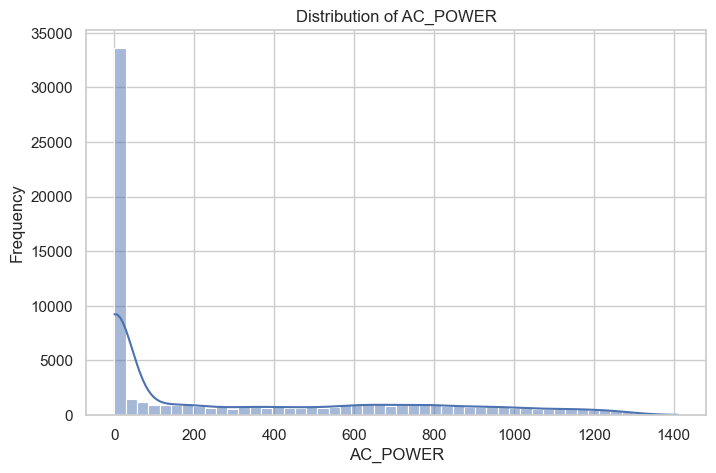

In [60]:
sns.set(style = "whitegrid")
features_for_eda = ['TOTAL_YIELD', 'DC_POWER', 'AC_POWER']

#Histograms for important features:
for col in features_for_eda:
    plt.figure(figsize = (8,5))
    sns.histplot(data[col], bins = 50, kde = True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

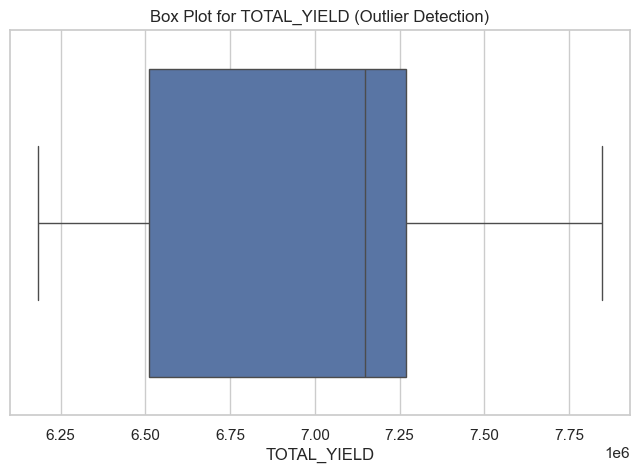

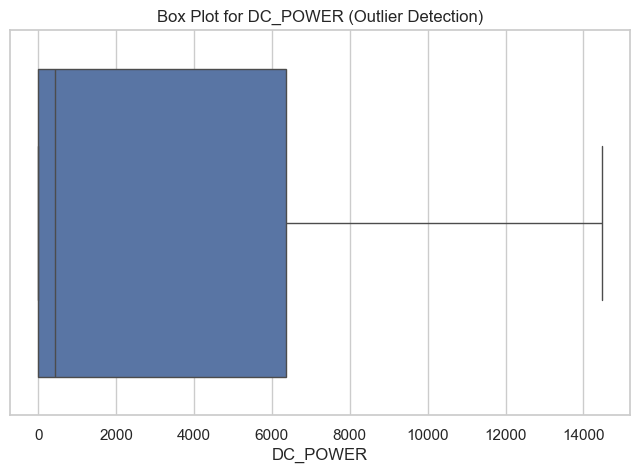

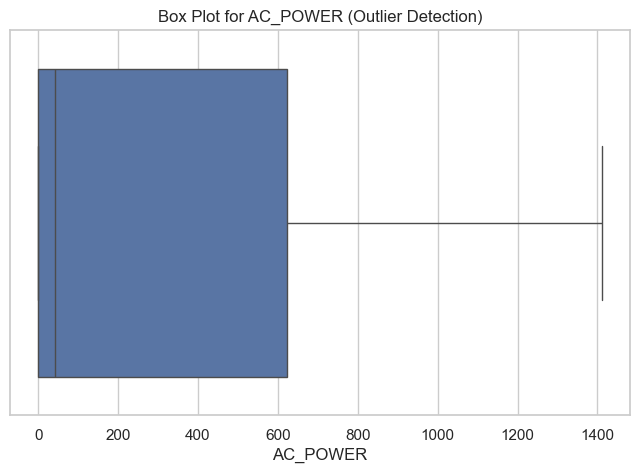

In [61]:
#To check for outliers in data:
for col in features_for_eda:
    plt.figure(figsize = (8,5))
    sns.boxplot(x = data[col])
    plt.title(f"Box Plot for {col} (Outlier Detection)")
    plt.show()

In [62]:
data[features_for_eda].describe()

,TOTAL_YIELD,DC_POWER,AC_POWER
count,6.877800e+04,68778.000000,68778.000000
mean,6.978712e+06,3147.426211,307.802752
std,4.162720e+05,4036.457169,394.396439
min,6.183645e+06,0.000000,0.000000
25%,6.512003e+06,0.000000,0.000000
50%,7.146685e+06,429.000000,41.493750
75%,7.268706e+06,6366.964286,623.618750
max,7.846821e+06,14471.125000,1410.950000


C:\Users\abhia\AppData\Local\Temp\ipykernel_26464\843898836.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data = data, x = 'hour', y = 'DC_POWER', estimator = 'mean', ci = None, label = 'DC_POWER')
C:\Users\abhia\AppData\Local\Temp\ipykernel_26464\843898836.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data = data, x = 'hour', y = 'AC_POWER', estimator = 'mean', ci = None, label = 'AC_POWER')


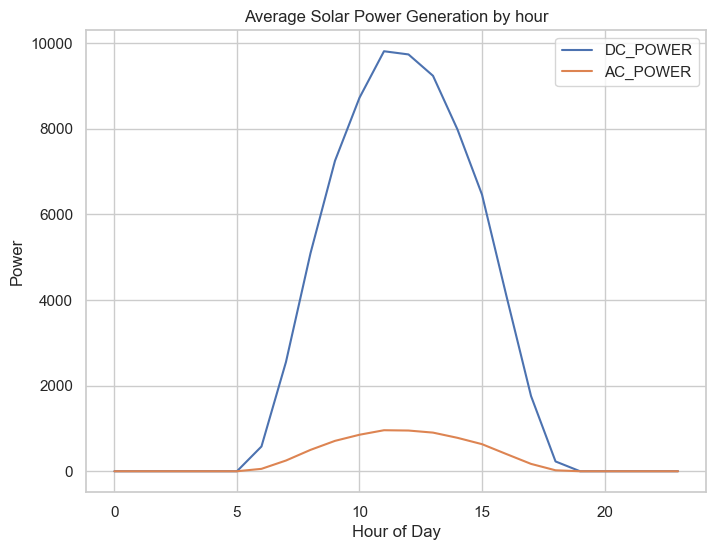

In [63]:
#analyzing solar generation patterns throughout the day
plt.figure(figsize = (8,6))
sns.lineplot(data = data, x = 'hour', y = 'DC_POWER', estimator = 'mean', ci = None, label = 'DC_POWER')
sns.lineplot(data = data, x = 'hour', y = 'AC_POWER', estimator = 'mean', ci = None, label = 'AC_POWER')
plt.title("Average Solar Power Generation by hour")
plt.xlabel("Hour of Day")
plt.ylabel("Power")
plt.legend()
plt.show()

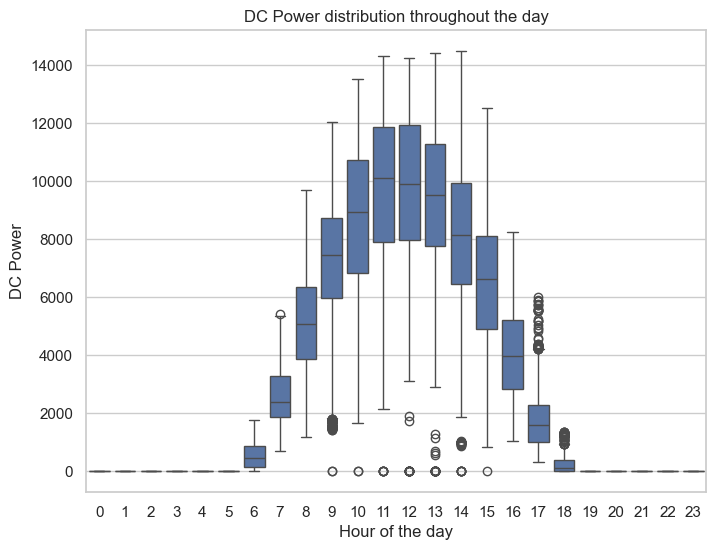

In [64]:
plt.figure(figsize = (8,6))
sns.boxplot(x = 'hour', y = 'DC_POWER', data = data)
plt.title("DC Power distribution throughout the day")
plt.xlabel("Hour of the day")
plt.ylabel("DC Power")
plt.show()

In [65]:
# here we notice that the power generation during the night time is negligible (or zero) and max when the sun is overhead

C:\Users\abhia\AppData\Local\Temp\ipykernel_26464\4135714289.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x = 'hour', y = 'TOTAL_YIELD', data = data, ci = None, estimator = 'mean', color = 'green')


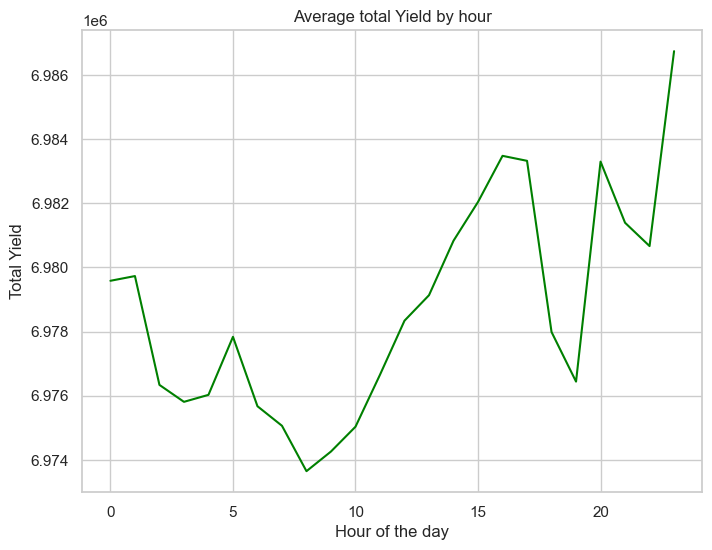

In [66]:
plt.figure(figsize = (8,6))
sns.lineplot(x = 'hour', y = 'TOTAL_YIELD', data = data, ci = None, estimator = 'mean', color = 'green')
plt.title("Average total Yield by hour")
plt.xlabel("Hour of the day")
plt.ylabel("Total Yield")
plt.show()

In [67]:
new_data = data.head(6000)

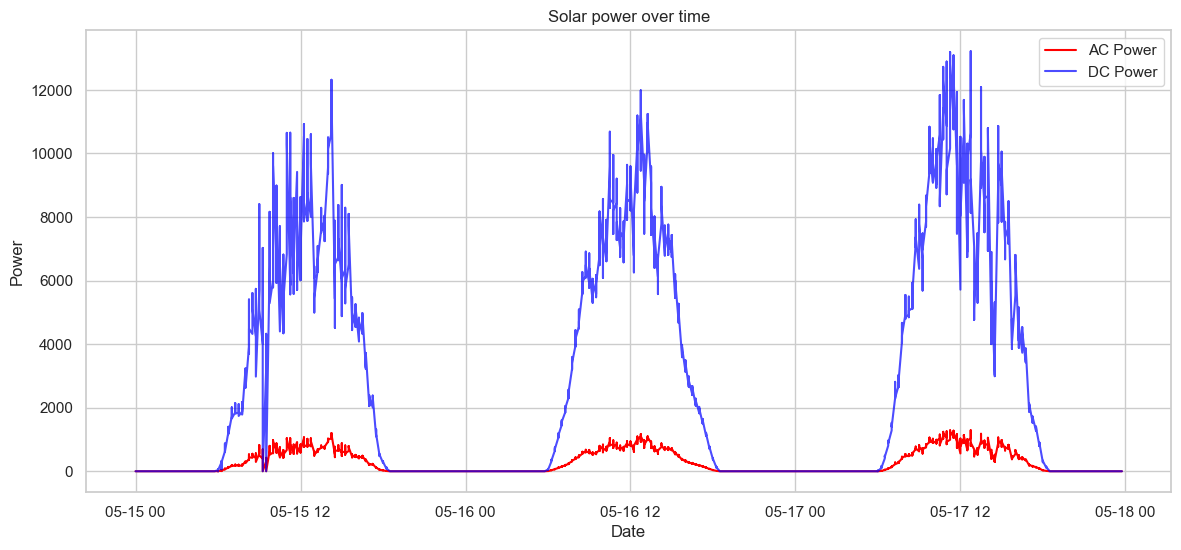

In [68]:
plt.figure(figsize = (14,6))
plt.plot(new_data['DATE_TIME'], new_data['AC_POWER'], label = "AC Power", color = 'red')
plt.plot(new_data['DATE_TIME'], new_data['DC_POWER'], label = "DC Power", color = 'blue', alpha = 0.7)
plt.title("Solar power over time")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Power")
plt.show()

In [69]:
print(data.isnull().sum())

DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
hour           0
day            0
dayofweek      0
month          0
year           0
dtype: int64


In [70]:
features = data[['DC_POWER', 'TOTAL_YIELD', 'hour', 'dayofweek', 'month', 'year']]
prediction = data['AC_POWER']

In [71]:
#train, test, split
X_train, X_test, y_train, y_test = train_test_split(features, prediction, test_size = 0.2, random_state = 42, shuffle = False)

In [72]:
Train_data = pd.concat([X_train, y_train], 
                       axis = 'columns',
                       names = ['hour', 'dayofweek', 'month', 'year', 'DC_POWER', 'TOTAL_YIELD'])
Train_data.head()

,DC_POWER,TOTAL_YIELD,hour,dayofweek,month,year,AC_POWER
0,0.0,6259559.0,0,4,5,2020,0.0
1,0.0,6183645.0,0,4,5,2020,0.0
2,0.0,6987759.0,0,4,5,2020,0.0
3,0.0,7602960.0,0,4,5,2020,0.0
4,0.0,7158964.0,0,4,5,2020,0.0


In [73]:
Train_data.describe()

,DC_POWER,TOTAL_YIELD,hour,dayofweek,month,year,AC_POWER
count,55022.000000,5.502200e+04,55022.000000,55022.000000,55022.000000,55022.0,55022.000000
mean,3211.556463,6.954373e+06,11.465123,2.988150,5.398204,2020.0,314.037961
std,4103.948725,4.140120e+05,6.851313,2.054705,0.489532,0.0,400.940870
min,0.000000,6.183645e+06,0.000000,0.000000,5.000000,2020.0,0.000000
25%,0.000000,6.476222e+06,6.000000,1.000000,5.000000,2020.0,0.000000
50%,449.598214,7.128535e+06,11.000000,3.000000,5.000000,2020.0,43.471429
75%,6468.785714,7.241969e+06,17.000000,5.000000,6.000000,2020.0,633.575000
max,14413.428570,7.802585e+06,23.000000,6.000000,6.000000,2020.0,1405.300000


In [74]:
LinReg = LinearRegression()
LinReg.fit(X_train, y_train)

y_pred_train = LinReg.predict(X_train)
y_pred = LinReg.predict(X_test)

In [75]:
mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print("Evaluation metrics: Train data")
print("Mean absolute error: ", mae_train)
print("Mean squared error: ", mse_train)
print("R-squared score: ", r2_train)

Evaluation metrics: Train data
Mean absolute error:  0.7132578139331861
Mean squared error:  1.1785305202570104
R-squared score:  0.9999926685804855


In [76]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluation metrics: Test data")
print("Mean absolute error: ", mae)
print("Mean squared error: ", mse)
print("R-squared score: ", r2)

Evaluation metrics: Test data
Mean absolute error:  0.7053040142696678
Mean squared error:  1.125676638062211
R-squared score:  0.9999915964216066


In [77]:
print("Model coefficients: ", LinReg.coef_)
print("Corresponding features: ", features.columns.values)

Model coefficients:  [ 9.76960217e-02 -3.08200635e-08  5.12627569e-04  3.25689875e-03
  1.27705137e-02  0.00000000e+00]
Corresponding features:  ['DC_POWER' 'TOTAL_YIELD' 'hour' 'dayofweek' 'month' 'year']


In [78]:
total_features = ['DC_POWER', 'TOTAL_YIELD', 'hour', 'dayofweek', 'month', 'year']
target = 'AC_POWER'

In [80]:
# Convert index to DatetimeIndex if it isn't already
data.index = pd.to_datetime(data.index)

# Define split date
split_date = data.index.max() - pd.Timedelta(days=2)

# Split the data
X_train = data.loc[data.index < split_date, total_features]
y_train = data.loc[data.index < split_date, target]
X_test = data.loc[data.index > split_date, total_features]
y_test = data.loc[data.index > split_date, target]

In [81]:
models = {
    'LinearReg' : LinearRegression(),
    'DecisionTree' : DecisionTreeRegressor(random_state = 42),
    'RandomForest' : RandomForestRegressor(n_estimators = 100, random_state = 42)
    }

results = {}